In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/README.dataset.txt
/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/README.roboflow.txt
/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/labels/construction-3-_mp4-219_jpg.rf.416dbf917b54d5895e2430fa0d6f1b66.txt
/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/labels/construction-1-_mp4-147_jpg.rf.a9062a80b06ac796f7afb269e5f18c53.txt
/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/labels/Movie-on-10-31-22-at-10_08-AM_mov-13_jpg.rf.91dc3b79da617fb2e4321f27f48f21f4.txt
/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/labels/2009_002778_jpg.rf.7c8977ed190a2ce4211ef58f66864066.txt
/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-rob

In [2]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.2 MB/s eta 0:00:00a 0:00:01


In [3]:
import os

# This lists all top-level folders in your input
print("Checking your input folders...")
print(os.listdir('/kaggle/input'))

Checking your input folders...
['datasets']


In [4]:
print(os.listdir('/kaggle/input/datasets'))

['snehilsanyal']


In [5]:
import yaml

# Creating the map based on your specific folder structure
data_config = {
    'train': '/kaggle/input/datasets/snehilsanyal/train/images',
    'val':   '/kaggle/input/datasets/snehilsanyal/valid/images',
    'test':  '/kaggle/input/datasets/snehilsanyal/test/images',
    'nc': 10, 
    'names': ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
}

with open('/kaggle/working/safer_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("Map created! The AI now knows where the helmets and vests are.")

Map created! The AI now knows where the helmets and vests are.


In [6]:
import os

# This will find the real path to your images
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in root and 'images' in root:
        print(f"REAL TRAIN PATH: {root}")
        break

REAL TRAIN PATH: /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/train/images


In [7]:
import yaml

# Update these paths with what the diagnostic told you!
# If the diagnostic said: /kaggle/input/datasets/snehilsanyal/css-data/train/images
# Then your base_path is: /kaggle/input/datasets/snehilsanyal/css-data/

base_path = '/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/' # <--- CHANGE THIS if needed

data_config = {
    'path': base_path, # This tells YOLO the "Root" folder
    'train': 'train/images',
    'val':   'valid/images', # Check if this should be 'val/images'
    'test':  'test/images',
    'nc': 10, 
    'names': ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
}

with open('/kaggle/working/safer_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("Map updated with Absolute Paths!")

Map updated with Absolute Paths!


In [8]:
from ultralytics import YOLO

# 1. Load the YOLOv11 Nano model 
# (This is the "brain" that will eventually live on your STM32)
model = YOLO('yolo11n.pt') 

# 2. Call the AI Engine to start the training
# It uses the 'safer_data.yaml' file you just perfected
model.train(
    data='/kaggle/working/safer_data.yaml', 
    epochs=25,    # 25 rounds of practice
    imgsz=320,    # Small size for high-speed hardware
    device=0      # Use the GPU 'Turbo' mode
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/safer_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d49887c4fb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0


image 1/114 /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/images/-1079-_png_jpg.rf.19092a3937930012f9fd9c1ce57f5a7b.jpg: 320x320 1 Hardhat, 2 NO-Safety Vests, 2 Persons, 7.5ms
image 2/114 /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/images/-1429-_png_jpg.rf.78a7894e86c79d018d80fa86f4d000f8.jpg: 320x320 2 Hardhats, 2 NO-Safety Vests, 2 Persons, 1 Safety Vest, 7.6ms
image 3/114 /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/images/-1969-_png_jpg.rf.41dd58ed3ae83df95fb2417c679d581f.jpg: 320x320 1 Hardhat, 1 NO-Mask, 1 NO-Safety Vest, 3 Persons, 7.8ms
image 4/114 /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/images/-1989-_png_jpg.rf.8cb3d6087bb86d08e693b4250fbf96e3.jpg: 320x320 4 Hardhats, 4 NO-Masks, 4 NO-Safety Vests, 4 Persons, 8.0ms
image 5/114 /kaggle/input/datasets/snehilsan

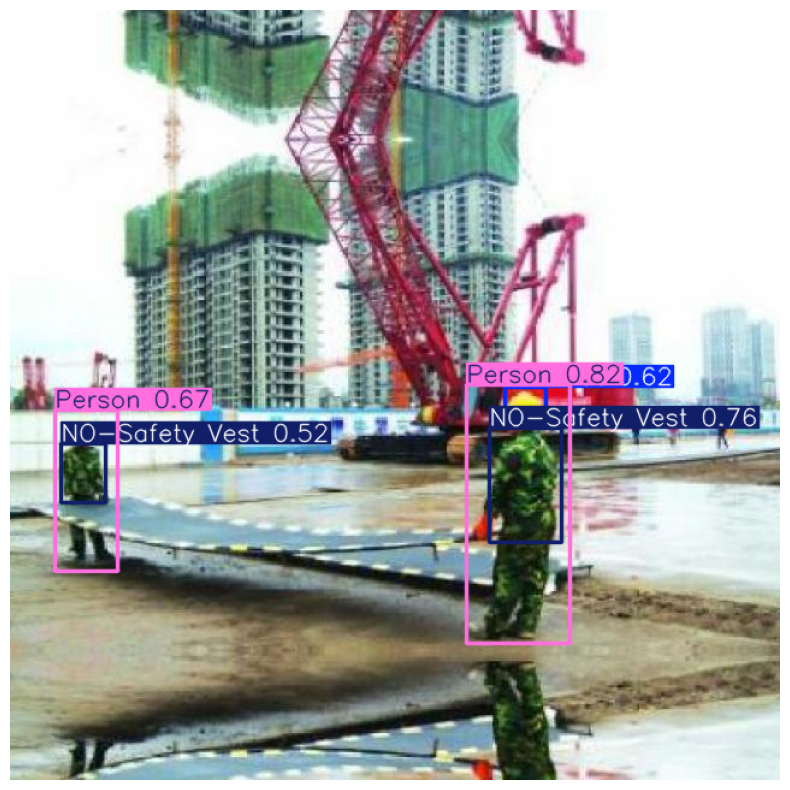

In [9]:
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# 1. Load your newly trained 'best' model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

# 2. Run a prediction on a random image from your validation set
# (We point it to the valid/images folder we mapped earlier)
results = model.predict(source='/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/images', save=True, imgsz=320, conf=0.4)

# 3. Show the first result
res = results[0]
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [1]:
import cv2
from ultralytics import YOLO
from IPython.display import display, Image

# 1. Load your trained model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

# 2. Open the laptop camera (0 is usually the default)
cap = cv2.VideoCapture(0)

print("Starting Camera... Press 'Interrupt' in the toolbar to stop.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # 3. Run AI on the current camera frame
        results = model(frame, stream=True, conf=0.4, imgsz=320)

        for r in results:
            annotated_frame = r.plot() # Draw the boxes

        # 4. Display the live feed in the notebook
        _, buffer = cv2.imencode('.jpg', annotated_frame)
        display(Image(data=buffer))
        
        # Clear the previous image to create a "video" effect
        from IPython.display import clear_output
        clear_output(wait=True)

except KeyboardInterrupt:
    cap.release()
    print("Camera stopped.")

ModuleNotFoundError: No module named 'ultralytics'